# El Contexto: Abril de 1912
Era la madrugada del 15 de abril de 1912. El RMS Titanic, el barco más grande y lujoso del mundo, se hundía en las heladas aguas del Atlántico Norte tras colisionar con un iceberg a las 23:40 del día anterior.

A bordo viajaban 2.224 personas entre pasajeros y tripulación. Solo 710 sobrevivirían. Las causas de la supervivencia diferencial no fueron aleatorias: el dinero, el género, la edad y la clase social marcaron quién vivía y quién moría.

Más de un siglo después, tú eres parte del equipo de investigadores de datos que analiza por primera vez el registro completo de pasajeros. Tu misión es responder preguntas históricas clave usando únicamente datos y visualizaciones.

## 🎯 Objetivos
Al finalizar esta actividad, el/la estudiante será capaz de:

*   Cargar y preparar un dataset real con Pandas para su visualización.

*   Seleccionar el tipo de gráfico adecuado según la naturaleza de los datos (categórico, numérico, relacional, distribución).

*   Implementar al menos 12 tipos diferentes de visualización usando Matplotlib, Seaborn.

*   Interpretar correctamente cada visualización y extraer conclusiones significativas.

*   Aplicar buenas prácticas: títulos, etiquetas de ejes, leyendas, paletas accesibles y tamaño adecuado.

### 📦El Dataset: Titanic - ⚙ Setup inicial

In [4]:
# Paso 1 — Descargar el dataset
import pandas as pd

# Uso del link del repositorio oficial de datasets de GitHub que tiene el mismo archivo
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Configuraciones para que se vea más ancho y no salte de línea
pd.set_option('display.max_columns', None)  # Muestra todas las columnas
pd.set_option('display.width', 1000)        # Estira el ancho de la pantalla

#### 🔍 Reto 1 — Exploración inicial

In [5]:
#Muestra de las 5 primeras lineas
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Conteo de filas y columnas
df.shape

(891, 12)

In [7]:
# Resumen técnico: Número de filas y columnas, nombres de las variables, nulos y qué tipo de dato contienen (número, texto, etc.).
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
# Tipo de variables
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [9]:
# Suma de los nulos encontrados
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
# Resumen estadístico de las columnas numéricas, mostrando valores como el promedio, la desviación estándar, el mínimo, el máximo y los cuartiles.
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Responder a las siguientes preguntas:

1.   ¿Cuántos pasajeros y cuántas columnas tiene el dataset?

1.   ¿Qué variables son numéricas y cuáles son categóricas?

2.   ¿Qué tipo de dato tiene cada columna?

1.   ¿Hay valores nulos? ¿En qué columnas?

2.   ¿Qué porcentaje de pasajeros sobrevivió?

---

    1R// Hay 891 pasajeros y 12 filas.

    2R// El id de los pasajeros, los supervivientes, la clase social, la edad, el número de hermanos, número de padres, y la tarifa de pasajero son de tipo númerico, los demás son tipo categória.

    3R//
    int: Id del pasajero, supervivientes, clase social, el número de hermanos y el número de padres.
    float: Edad y la tarifa del pasajero
    object: Nombre, ticket, cabina y los embarcados
    
    4R// Existen valores nulos en la edad y la cabina

    5R// El 38% de los pasajeros sobrevivió

### 📊 Guía de Gráficos: De lo Básico a lo Avanzado
Antes de analizar quién sobrevivió, se debe de entender quiénes estaban en el barco.

#### PARTE I — El Perfil de los Pasajeros

##### **Pregunta 1  —  ¿Cómo era la composición del pasaje?**

El Titanic tenía tres clases de billete con precios y comodidades muy diferentes. La Primera Clase ocupaba los camarotes superiores con acceso a cubiertas de paseo; la Tercera Clase viajaba en las entrañas del barco, a menudo con las escotillas cerradas durante la evacuación.  

¿Cómo se distribuían los pasajeros entre las tres clases? ¿Era el Titanic un barco igualitario en número de plazas, o había alguna clase dominante?

---

¿Qué tipo de gráfico se elegiría y por qué?

R// Elegiría un gráfico de barras porque la variable de Clase es una variable categórica. Un gráfico de barras permite comparar visualmente la cantidad de personas de cada categoría, haciendo que la disparidad entre la Tercera Clase y las demás sea evidente al primer vistazo.

---

¿Qué conclusión se extrae del gráfico?

R// La conclusión principal es que el Titanic tenía una estructura social piramidal y no igualitaria.

*   Existía una clase dominante en número: la Tercera Clase.

*   El barco funcionaba principalmente como un medio de transporte masivo para pasajeros de bajos recursos, mientras que las clases altas (1ª y 2ª) representaban una proporción mucho menor del pasaje total.

/tmp/ipykernel_2171/1967290305.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette='viridis')


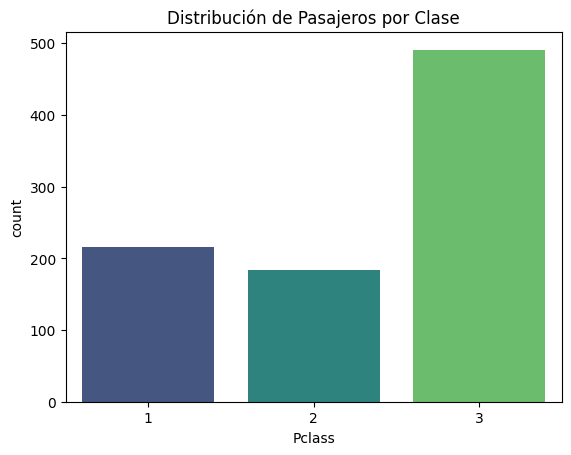

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creación del gráfico de barras automático
sns.countplot(x='Pclass', data=df, palette='viridis')
plt.title('Distribución de Pasajeros por Clase')
plt.show()

##### **Pregunta 2  —  ¿Qué edades tenían los pasajeros?**

En 1912, el Titanic atraía perfiles muy distintos: familias adineradas que regresaban de Europa, emigrantes que buscaban una nueva vida en América, y aventureros de todas las edades.

¿Cómo se distribuían las edades de los pasajeros? ¿El barco era predominantemente joven, maduro, o había una mezcla? ¿Existen valores extremos que llamen la atención?

---

¿Qué tipo de gráfico se elegiría y por qué?

R// Elegiría un histograma porque la variable de edad es tipo numérica continua. Un histograma es el gráfico ideal para este tipo de datos, ya que agrupa las edades en intervalos y muestra la frecuencia de personas en cada rango, permitiendo ver fácilmente la forma de la distribución.

---

¿Qué conclusión se extrae del gráfico?

R// Se extraen tres conclusiones principales:

*   Población predominantemente joven-adulta: La mayoría de pasajeros se concentraba entre los 20 y 40 años (el promedio es de ~29.7 años y la mediana es de 28 años). Esto coincide con el perfil de personas en edad de trabajar y emigrar.

*   Variedad generacional: A pesar de ser un barco joven, había una mezcla notable de etapas. Se observa la presencia de niños pequeños (el mínimo es de 0.42 años) que viajaban con sus familias, y una presencia mucho más reducida de adultos mayores.

*   Valores extremos: Destaca un valor extremo, un pasajero de 80 años, lo cual era una edad muy avanzada para la esperanza de vida de la época, situándolo como un caso aislado en comparación con el resto.

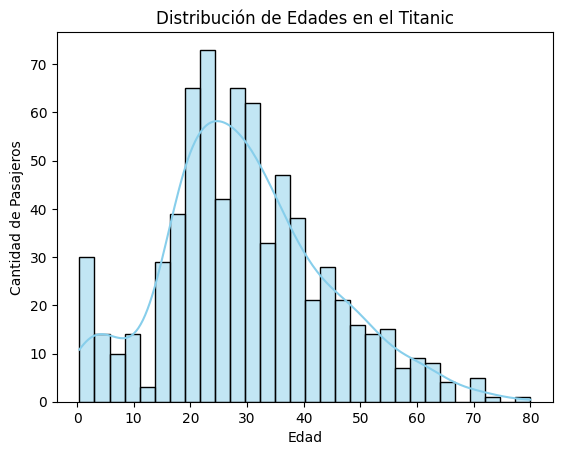

In [12]:
# Histograma con curva de densidad
sns.histplot(df['Age'].dropna(), kde=True, color='skyblue', bins=30)
plt.title('Distribución de Edades en el Titanic')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Pasajeros')
plt.show()

##### **Pregunta 3  —  ¿Existía diferencia de edad entre clases sociales?**

La clase del billete no solo determinaba el confort a bordo: también reflejaba una etapa vital diferente. Los pasajeros de Primera Clase solían ser personas establecidas económicamente, mientras que la Tercera reunía a jóvenes que emigraban en busca de oportunidades.

¿Tenían edades similares los pasajeros de las tres clases, o había diferencias
significativas? ¿Cómo se compara la dispersión de edades entre clases?

---

¿Qué tipo de gráfico se elegiría y por qué?

R// Elegiría un gráfico de caja porque se debe de comparar la variable edad dividida por la variable clase. Este diagrama muestra de un solo vistazo la mediana, los cuartiles y la dispersión para cada una de las tres clases de forma independiente, permitiendo compararlas una al lado de la otra fácilmente.

---

¿Qué conclusión se extrae del gráfico?

*   A mayor estatus social, mayor edad promedio: Existe una relación directa entre la clase del billete y la etapa de la vida de los pasajeros. Los pasajeros de Primera Clase eran notablemente más maduros en promedio que los de Segunda, y estos a su vez eran mayores que los de Tercera Clase.

*   Diferencia en la dispersión vital: La Tercera Clase muestra una concentración de edades mucho más joven y homogénea. Por el contrario, la Primera Clase muestra una mayor dispersión, lo que refleja que, aunque el perfil general era de adultos mayores establecidos, también viajaban familias con rangos de edad muy variados.

/tmp/ipykernel_2171/272455552.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=df, palette='Set2')


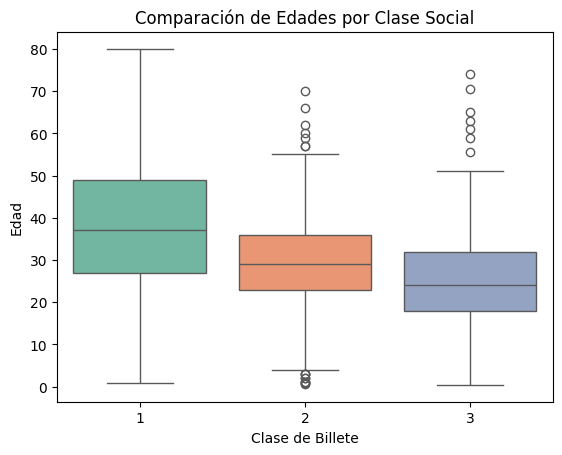

In [13]:
# Crear¡ción de caja para comparar edades por clase
sns.boxplot(x='Pclass', y='Age', data=df, palette='Set2')
plt.title('Comparación de Edades por Clase Social')
plt.xlabel('Clase de Billete')
plt.ylabel('Edad')
plt.show()

#### 💰 PARTE II — El Dinero a Bordo  

##### **Pregunta 4  —  ¿Cuánto se pagó por viajar en el Titanic?**

El billete más caro documentado fue de 512 libras, el equivalente a más de 70.000 euros actuales. El más barato rondaba las 5 libras. Esta diferencia de más de 100 veces no era solo económica: determinaba el acceso a los botes salvavidas.

¿Cómo se distribuyen las tarifas pagadas? ¿Era la mayoría de pasajeros de bajo poder adquisitivo? ¿Cómo se comportan los valores extremos?

---

¿Qué tipo de gráfico se elegiría y por qué?

R// Elegiría un histograma con curva de densidad debido a que permite visualizar la frecuencia acumulada en los rangos inferiores y la extensión del eje horizontal provocada por los valores atípicos, exponiendo la asimetría de los datos en una sola representación.

¿Qué conclusión se extrae del gráfico?

*   **Predominio de bajo poder adquisitivo:** El 75% de los pasajeros se concentra por debajo de las 30 libras, mostrando que la inmensa mayoría del pasaje viajaba con tarifas mínimas.

*   **Brecha económica extrema:** El valor aislado de 510 libras actúa como un outlier radical, lo que demuestra la existencia de una élite económica con acceso a condiciones de súper-lujo, totalmente desconectada de la realidad del pasajero promedio.

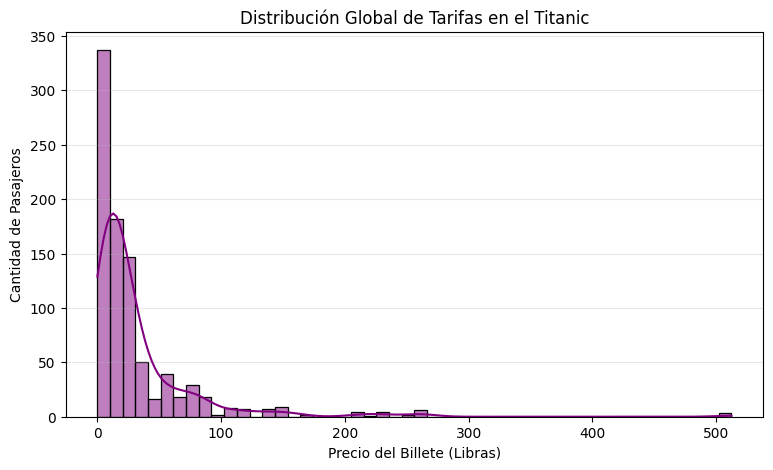

In [14]:
plt.figure(figsize=(9, 5))
# Un solo gráfico que muestra la distribución completa y el sesgo
sns.histplot(data=df, x='Fare', bins=50, kde=True, color='purple')

plt.title('Distribución Global de Tarifas en el Titanic')
plt.xlabel('Precio del Billete (Libras)')
plt.ylabel('Cantidad de Pasajeros')
plt.grid(axis='y', alpha=0.3)
plt.show()

##### **Pregunta 5  —  ¿La clase social determinaba cuánto se pagaba?**

Parece obvio que Primera Clase pagaba más, pero ¿cuánto más exactamente? ¿Y
cómo era la variabilidad dentro de cada clase? ¿Todos los de Primera pagaban lo
mismo, o había grandes diferencias incluso entre iguales?

Comparar las tarifas pagadas entre las tres clases mostrando no solo el valor central sino también la dispersión y los valores atípicos.

---

¿Qué tipo de gráfico se elegiría y por qué?

R// Elegiría un gráfico Boxplot porque compara directamente la distribución de una variable numérica (tarifa) frente a una categórica (clase), mostrando en un solo eje la mediana, los rangos de precios y los valores atípicos de cada grupo.

¿Qué conclusión se extrae del gráfico?

*   **Brecha abismal entre clases:** Las medianas de Segunda y Tercera Clase son bajas, idénticas y comprimidas, lo que indica tarifas estandarizadas y baratas. La Primera Clase opera en una escala de precios radicalmente superior.

*   **Desigualdad interna en Primera Clase:** Mientras las clases bajas muestran una dispersión mínima, la Primera Clase exhibe una caja sumamente estirada y llena de outliers. Esto demuestra que el acceso a la Primera Clase no era homogéneo; coexistían pasajeros con billetes base y una élite con camarotes de súper-lujo.

/tmp/ipykernel_2171/978703209.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2')


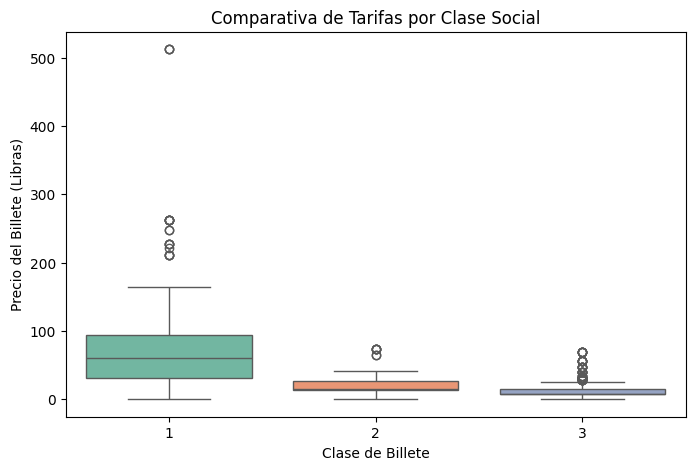

In [15]:
plt.figure(figsize=(8, 5))
# Gráfico de caja para comparar la distribución de tarifas por clase
sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2')

plt.title('Comparativa de Tarifas por Clase Social')
plt.xlabel('Clase de Billete')
plt.ylabel('Precio del Billete (Libras)')
plt.show()

##### **Pregunta 6  —  ¿La riqueza está relacionada con la edad?**

¿Los pasajeros más mayores tendían a pagar tarifas más altas? ¿O la relación entre edad y riqueza era más compleja? Esta pregunta busca explorar una posible relación entre dos variables numéricas continuas.

Explora la relación entre la edad de los pasajeros y la tarifa que pagaron. ¿Observas algún patrón? ¿Hay grupos que se comporten de forma diferente?

---

¿Qué tipo de gráfico se elegiría y por qué?

R// Elegiría un gráfico de dispersión, porque analiza la relación, tendencia o correlación entre dos variables numéricas continuas (edad y tarifa).

¿Qué conclusión se extrae del gráfico?

*   **Inexistencia de correlación lineal:** La edad no determina el precio del billete de forma general; la mayor densidad de pasajeros se concentra en la base inferior (tarifas bajas) de manera uniforme en todas las edades.

*   **Patrón de riqueza exclusivo por clase:** En Segunda y Tercera Clase las tarifas se mantienen bajas y constantes sin importar la edad. En cambio, en Primera Clase la dispersión aumenta: las tarifas de súper-lujo fueron adquiridas casi exclusivamente por adultos de edad madura, indicando que la acumulación de riqueza extrema estaba ligada a una mayor estabilidad vital.

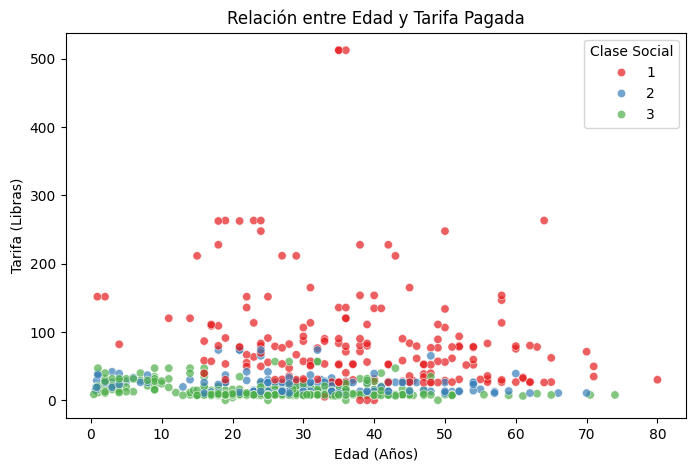

In [16]:
plt.figure(figsize=(8, 5))
# Gráfico de dispersión cruzando Edad y Tarifa, diferenciando por Clase
sns.scatterplot(data=df, x='Age', y='Fare', hue='Pclass', palette='Set1', alpha=0.7)

plt.title('Relación entre Edad y Tarifa Pagada')
plt.xlabel('Edad (Años)')
plt.ylabel('Tarifa (Libras)')
plt.legend(title='Clase Social')
plt.show()

#### ⚓ PARTE III — La Noche del Hundimiento  

##### **Pregunta 7  —  ¿Cuál fue la tasa de supervivencia global?**

Cuando el Titanic se hundió definitivamente a las 02:20 de la madrugada, solo
quedaban en el agua los botes salvavidas y miles de personas en el océano a -2ºC. En menos de dos horas, la mayoría habría muerto de hipotermia.

De todos los pasajeros del dataset, ¿qué proporción sobrevivió y qué proporción no lo hizo? Muéstralo de forma que quede claro el peso relativo de cada grupo.

---

¿Qué tipo de gráfico se elegiría y por qué?

R// Elegiría un gráfico de sectores para mostrar la composición de un "todo" dividido en pocas categorías (Superviviente vs. Fallecido). Permite visualizar el peso relativo, la proporción y el porcentaje de cada grupo respecto al total de pasajeros.

¿Qué conclusión se extrae del gráfico?

*   **Mortalidad mayoritaria:** El peso relativo de los fallecidos fue drásticamente superior, alcanzando el 61.62% del total de pasajeros.

*   **Minoría superviviente:** Solo el 38.38% logró salvarse, lo que demuestra que la evacuación fue insuficiente y que el desenlace de la tragedia fue mortal para la mayoría de las personas a bordo.

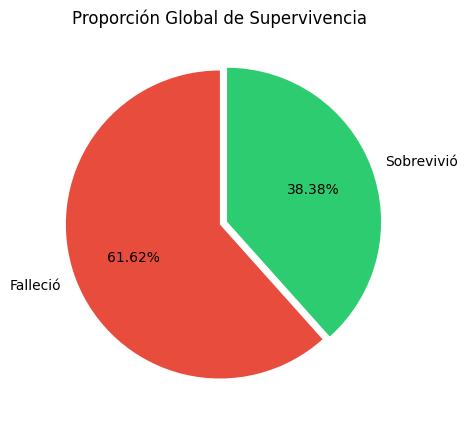

In [17]:
# Conteo de frecuencias de la columna 'Survived'
data = df['Survived'].value_counts()

plt.figure(figsize=(5, 5))
# Gráfico circular con porcentajes
plt.pie(data, labels=['Falleció', 'Sobrevivió'], autopct='%1.2f%%',
        colors=['#e74c3c', '#2ecc71'], startangle=90, explode=(0, 0.05))

plt.title('Proporción Global de Supervivencia')
plt.show()

##### **Pregunta 8  —  ¿Importó la clase social para sobrevivir?**

Los botes salvavidas estaban situados en la cubierta de Botes, a la que los pasajeros de Tercera Clase apenas tenían acceso directo. Muchos pasajeros de clase baja no llegaron nunca a cubierta a tiempo, bloqueados por barreras físicas y lingüísticas.

¿Fue igual de probable sobrevivir si viajabas en Primera que en Tercera Clase? ¿Cómo varió la supervivencia entre clases, tanto en número absoluto como en proporción?

---

¿Qué tipo de gráfico se elegiría y por qué?

R// Elegiría un gráfico de barras agrupadas porque compara de forma directa variables categóricas (clase frente a Supervivientes), mostrando en un solo plano tanto el volumen absoluto de personas como la proporción relativa de supervivencia dentro de cada clase.

¿Qué conclusión se extrae del gráfico?

*   **Brecha proporcional de supervivencia:** La probabilidad de salvarse estuvo determinada por el estatus; en Primera Clase la mayoría de los pasajeros sobrevivió, en Segunda Clase la distribución fue equitativa, y en Tercera Clase la mayoría falleció.

*   **Mortalidad masiva en clase baja:** La Tercera Clase concentra la mayor cantidad absoluta y relativa de víctimas del barco, confirmando el impacto de las barreras físicas y de acceso a los botes salvavidas durante la evacuación.

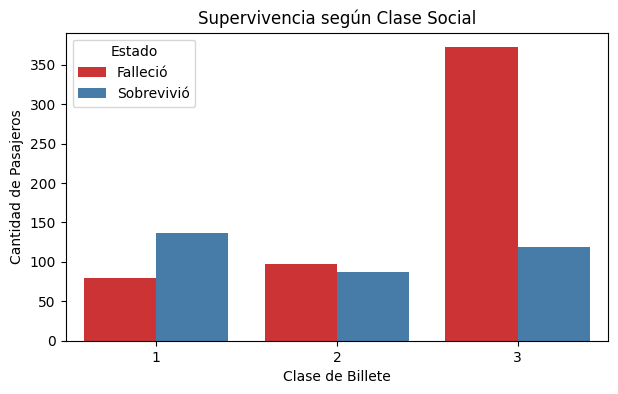

In [18]:
plt.figure(figsize=(7, 4))
# Gráfico de barras que contrasta la cantidad de sobrevivientes y fallecidos por clase
sns.countplot(data=df, x='Pclass', hue='Survived', palette='Set1')

plt.title('Supervivencia según Clase Social')
plt.xlabel('Clase de Billete')
plt.ylabel('Cantidad de Pasajeros')
plt.legend(title='Estado', labels=['Falleció', 'Sobrevivió'])
plt.show()

##### **Pregunta 9  —  ¿Se cumplió el protocolo 'mujeres y niños primero'?**

El Código de Burkitt, una convención marítima no escrita, dictaba que en caso de naufragio se evacuaría primero a mujeres y niños. El capitán Edward Smith ordenó seguir este protocolo. Pero ¿se aplicó de forma universal, o dependió también de la clase?

Analiza cómo varió la supervivencia según el sexo del pasajero, desglosando además por clase. ¿El protocolo se cumplió igual en todas las clases?

---

¿Qué tipo de gráfico se elegiría y por qué?

R// ELegiría un gráfico de barras porque dividir el análisis en tres paneles (uno por clase) permite comparar si la prioridad de supervivencia otorgada a las mujeres varió o se mantuvo constante según el estatus social.

¿Qué conclusión se extrae del gráfico?

*   **Cumplimiento general del protocolo:** Sí, el protocolo "mujeres y niños primero" se aplicó de forma masiva en todo el barco. En las tres clases sociales, la proporción de mujeres supervivientes es drásticamente superior a la de los hombres.

*   **Filtro letal por clase social:** El éxito del protocolo estuvo condicionado por la riqueza. En Primera y Segunda Clase la protección femenina fue casi absoluta, mientras que en Tercera Clase la cantidad de mujeres fallecidas fue masiva, demostrando que el estatus debilitó la efectividad de la evacuación.

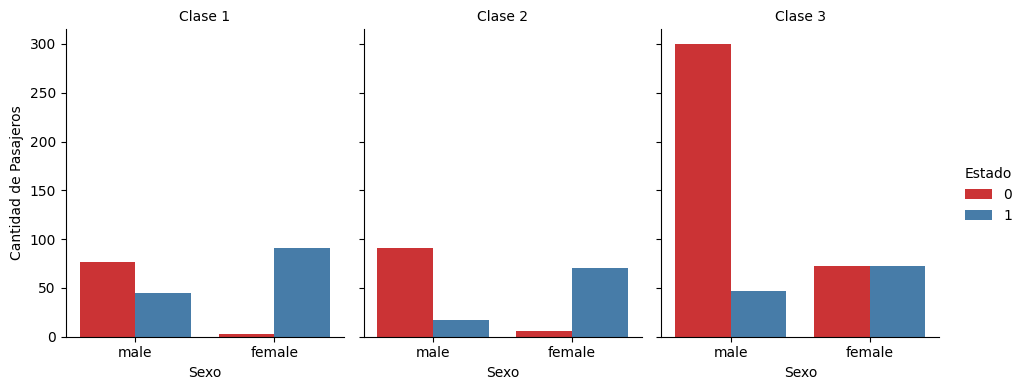

In [19]:
# Gráfico de barras por paneles para analizar Sexo vs Supervivencia por cada Clase
g = sns.catplot(
    data=df, x='Sex', hue='Survived', col='Pclass',
    kind='count', palette='Set1', height=4, aspect=0.8
)
g.set_axis_labels("Sexo", "Cantidad de Pasajeros")
g.set_titles("Clase {col_name}")
g._legend.set_title("Estado")
# Renombrar leyenda internamente si es necesario (0: Falleció, 1: Sobrevivió)
plt.show()

##### **Pregunta 10  —  ¿Tuvo la edad algún papel en la supervivencia?**

El protocolo 'mujeres y niños primero' menciona explícitamente a los niños. Pero la realidad de una evacuación de pánico es caótica. ¿La edad realmente marcó una diferencia? ¿Hubo tramos de edad con mayores tasas de supervivencia?

Compara la distribución de edades entre los pasajeros que sobrevivieron y los que no lo hicieron. ¿En qué tramos de edad fue mayor la supervivencia?

---

¿Qué tipo de gráfico se elegiría y por qué?

R// Elegiría un histograma superpuesto con curvas de densidad (KDE) porque contrasta una variable numérica continua (edad) dividida en dos grupos categóricos (Supervivientes). Permite identificar los rangos de edad exactos donde las distribuciones se cruzan, mostrando dónde hubo mayor proporción de muertes o salvaciones.

¿Qué conclusión se extrae del gráfico?

*   **Efectividad real en la protección infantil:** El tramo de 0 a 10 años presenta la mayor tasa de supervivencia de todo el gráfico, demostrando que la prioridad otorgada a los niños en el protocolo de evacuación se cumplió con éxito.

*   **Alta vulnerabilidad en jóvenes y ancianos:** El tramo entre los 18 y 32 años concentra el mayor volumen absoluto de fallecidos, un patrón de baja probabilidad de salvación que se agudiza en los adultos mayores de 60 años.

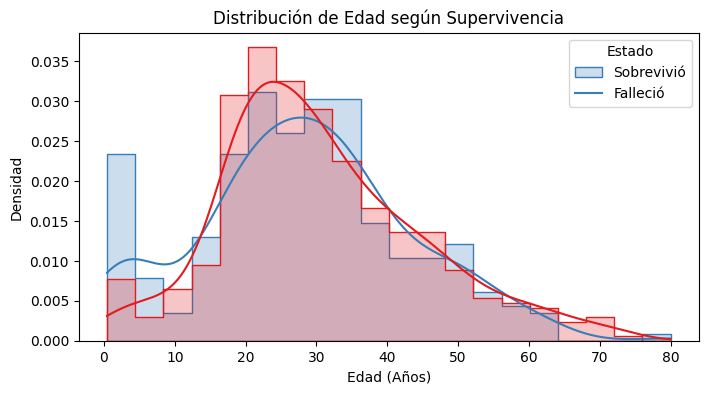

In [20]:
plt.figure(figsize=(8, 4))
# Histograma superpuesto para comparar edades de supervivientes vs fallecidos
sns.histplot(data=df, x='Age', hue='Survived', kde=True, element='step', stat='density', common_norm=False, palette='Set1')

plt.title('Distribución de Edad según Supervivencia')
plt.xlabel('Edad (Años)')
plt.ylabel('Densidad')
plt.legend(title='Estado', labels=['Sobrevivió', 'Falleció'])
plt.show()

#### 📊 PARTE IV — La Noche del Hundimiento  

##### **Pregunta 11  —  ¿Qué variables numéricas están más relacionadas entre sí?**

En ciencia de datos, antes de construir cualquier modelo, es fundamental entender qué variables se mueven juntas. Algunas relaciones son obvias (tarifa y clase), otras son inesperadas.

Explora las correlaciones entre todas las variables numéricas del dataset de una sola vez: survived, pclass, age, sibsp, parch y fare. ¿Qué par de variables presenta la correlación más fuerte? ¿Cuál es la más sorprendente?

---

¿Qué tipo de gráfico se elegiría y por qué?

R// Elegiría un Heatmap debido a que evalua múltiples variables numéricas simultáneamente. Transforma los coeficientes numéricos de correlación en una escala de colores, permitiendo identificar la fuerza y dirección de las relaciones entre todos los pares de variables.

¿Qué Par de variables te sorprendió más? ¿Por qué crees que están relacionadas?

*   **SibSp (Hermanos/Esposos) & Parch (Padres/Hijos):** Presenta una correlación positiva moderada-fuerte (cercana a 0.41).

*   **Por qué están relacionadas:** Indica que quienes viajaban acompañados no lo hacían solos con su pareja o hermanos, sino como parte de núcleos familiares completos, afectando directamente la asistencia y supervivencia durante la evacuación.

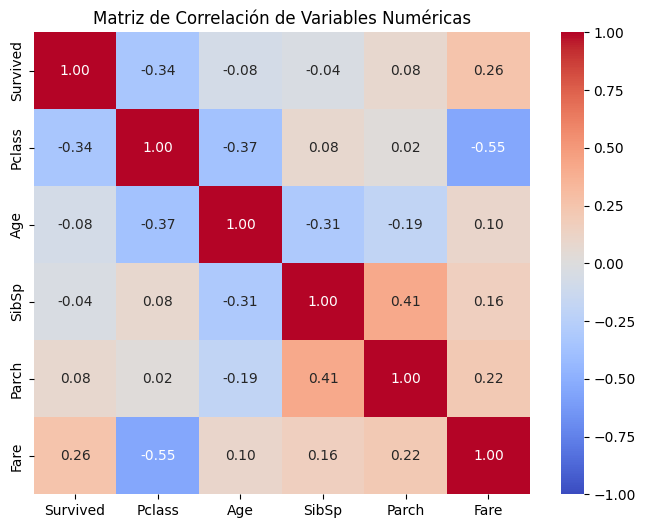

In [21]:
plt.figure(figsize=(8, 6))
# Calcular matriz de correlación solo para las columnas numéricas especificadas
columnas_num = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
matriz_corr = df[columnas_num].corr()

# Dibujar el mapa de calor con anotaciones numéricas
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

##### **Pregunta 12  —  ¿Dónde embarcaron los pasajeros que sobrevivieron?**

El Titanic hizo escala en tres puertos antes de cruzar el Atlántico: Southampton (S) en Inglaterra, Cherburgo (C) en Francia, y Queenstown (Q) en Irlanda. El tipo de pasajero variaba notablemente según el puerto: los emigrantes irlandeses embarcaban mayoritariamente en Queenstown; las familias adineradas, en Cherburgo.

¿Existió alguna relación entre el puerto de embarque, la clase del billete y la tasa de supervivencia? Visualiza estas tres variables simultáneamente.  

---

¿Qué tipo de gráfico se elegiría y por qué?

R// Un gráfico de barras por paneles debido a que permite cruzar tres variables en un mismo lienzo: el tamaño de la familia en el eje X, el puerto de embarque en las columnas, y la tasa promedio de supervivencia en el eje Y.

¿Viajar acompañado era una ventaja o una desventaja? ¿Qué te dice el gráfico?

*   **Ventaja en familias pequeñas:** El gráfico demuestra que viajar acompañado era una ventaja, pero con un límite, las familias pequeñas (1 a 3 acompañantes) tienen las tasas de supervivencia más altas en todos los puertos, ya que la ayuda mutua facilitó el acceso a los botes.

*   **Desventaja en familias numerosas:** Al superar los 4 miembros, la supervivencia se desploma drásticamente, especialmente en (S). Mantener unido a un grupo grande en el caos de la evacuación resultó ser un filtro mortal.

/tmp/ipykernel_2171/1133907098.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


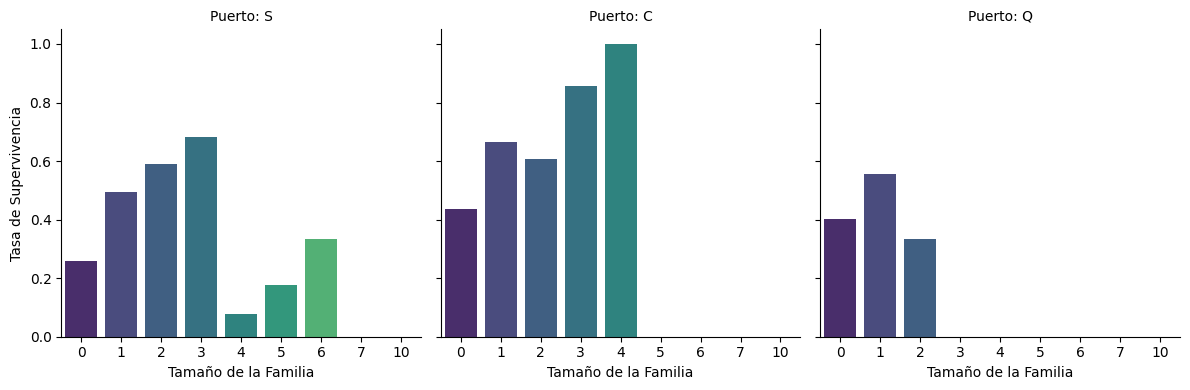

In [22]:
# Crear variable unificada de tamaño de familia
df['FamilySize'] = df['SibSp'] + df['Parch']

# Un solo gráfico que conecta familia, puerto y supervivencia
g = sns.catplot(
    data=df, x='FamilySize', y='Survived', col='Embarked',
    kind='bar', palette='viridis', errorbar=None, height=4, aspect=1
)
g.set_axis_labels("Tamaño de la Familia", "Tasa de Supervivencia")
g.set_titles("Puerto: {col_name}")
plt.show()

##### **Pregunta 13  —  ¿Viajar en familia protegía o perjudicaba?**

Algunos testimonios de supervivientes relatan que las familias numerosas tardaron más en llegar a los botes porque no querían separarse. Otros cuentan que los padres entregaron a sus hijos a los marineros antes de quedarse atrás. ¿Los datos respaldan alguna de estas hipótesis?

Las columnas sibsp (hermanos/cónyuge) y parch (padres/hijos) indican el tamaño del grupo familiar. ¿Cómo se relaciona el tamaño familiar con la supervivencia? ¿Había ventaja en viajar solo?

---

¿Qué tipo de gráfico se elegiría y por qué?

R// Un gráfico de barras de frecuencias que visualice de forma lineal y directa cómo cambia la probabilidad de sobrevivir a medida que aumenta el número de familiares a bordo, identificando con el punto de inflexión donde el grupo familiar pasa de ser una ventaja a un peligro.

¿Viajar acompañado era una ventaja o una desventaja? ¿Qué te dice el gráfico?

*   **Ventaja en familias de 2 a 4 miembros:** El gráfico muestra que las tasas de supervivencia alcanzan su punto máximo (cercano al 50%) en estas familias; la ayuda mutua y el esfuerzo coordinado facilitaron el acceso a los botes. Viajar completamente solo representaba una desventaja frente a estos grupos.

*   **Filtro mortal en familias de 5 o más miembros:** La supervivencia se desploma drásticamente a niveles mínimos, respaldando la hipótesis de que la negativa a separarse y la dificultad de mover grupos grandes costaron la vida de las familias numerosas.

/tmp/ipykernel_2171/2100035493.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='FamilySize', y='Survived', palette='Blues_d', errorbar=None)


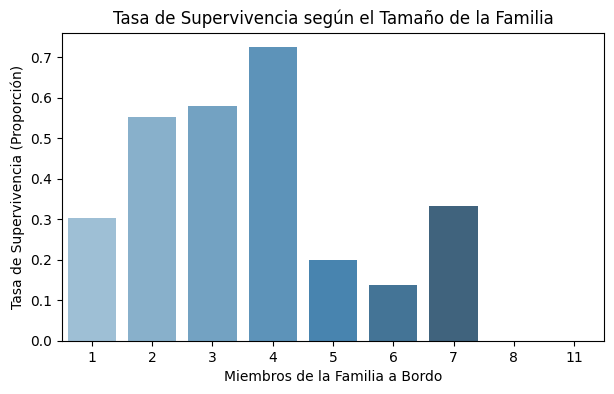

In [23]:
# Crear la variable unificada del tamaño de la familia
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 para incluir al propio pasajero

plt.figure(figsize=(7, 4))
# Gráfico de barras que calcula la tasa promedio de supervivencia por tamaño familiar
sns.barplot(data=df, x='FamilySize', y='Survived', palette='Blues_d', errorbar=None)

plt.title('Tasa de Supervivencia según el Tamaño de la Familia')
plt.xlabel('Miembros de la Familia a Bordo')
plt.ylabel('Tasa de Supervivencia (Proporción)')
plt.show()

#### 🧭 PARTE V — La Noche del Hundimiento  

##### **Pregunta 14  —  ¿Cuál es tu historia visual del Titanic?**

Diseña primero el dashboard en papel (boceto) antes de codificarlo. Decide:


*   ¿Qué 4–6 hallazgos son los más importantes para contar?

*   ¿Qué gráfico es el más adecuado para cada uno?

*   ¿Cómo los organizarías espacialmente (filas y columnas)?


¿Qué historia cuenta tu dashboard? Escribe 3–5 líneas explicando tus hallazgos principales como si se los explicaras a alguien que no sabe de datos

---

*   Los hallazgos más importantes son:

    La brecha económica (Tarifas por Clase): El Gráfico de caja (Boxplot) para evidenciar la enorme dispersión y los precios de súper-lujo exclusivos de la Primera Clase.

    El factor de supervivencia global: El Gráfico circular (Pie chart) que muestre de forma contundente que la mayoría de los pasajeros no logró sobrevivir.

    La regla de oro y su sesgo (Género y Clase): El Gráfico de barras por paneles (catplot de conteo) que demuestre que el protocolo "mujeres primero" funcionó, pero fue mucho más efectivo en las clases altas.

    El dilema familiar (Tamaño familiar): El Gráfico de barras (Bar plot de proporción) que exponga cómo las familias pequeñas tenían ventaja, mientras que las numerosas sufrieron una mortalidad total.

*   Organización Espacial (Layout del Dashboard)

    Para el lienzo de código se usará una cuadrícula de 2 filas y 2 columnas que se lee de forma natural de izquierda a derecha y de arriba abajo:

    Fila 1, Columna 1: Gráfico Circular (Contexto global de mortalidad).

    Fila 1, Columna 2: Gráfico de Caja (La diferencia económica entre clases).

    Fila 2, Columna 1: Gráfico de Barras por Paneles (El peso del género y la clase).

    Fila 2, Columna 2: Gráfico de Línea/Barras (El impacto del tamaño de la familia).

*   ¿Qué historia cuenta tu dashboard?

    R// El dashboard cuenta que el destino en el Titanic no dependió de la suerte, sino de quién eras y con quién ibas. Aunque la mayoría de los pasajeros falleció, las mujeres y niños tuvieron prioridad absoluta para salvarse, pero este código falló en la Tercera Clase debido a las barreras del barco. Finalmente, la estructura familiar revela que viajar con un grupo pequeño de apoyo salvaba vidas, mientras que las familias numerosas quedaron atrapadas en la tragedia.

/tmp/ipykernel_2171/2581745554.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2', ax=axes[0, 1])
/tmp/ipykernel_2171/2581745554.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='FamilySize', y='Survived', palette='Blues_d', errorbar=None, ax=axes[1, 1])


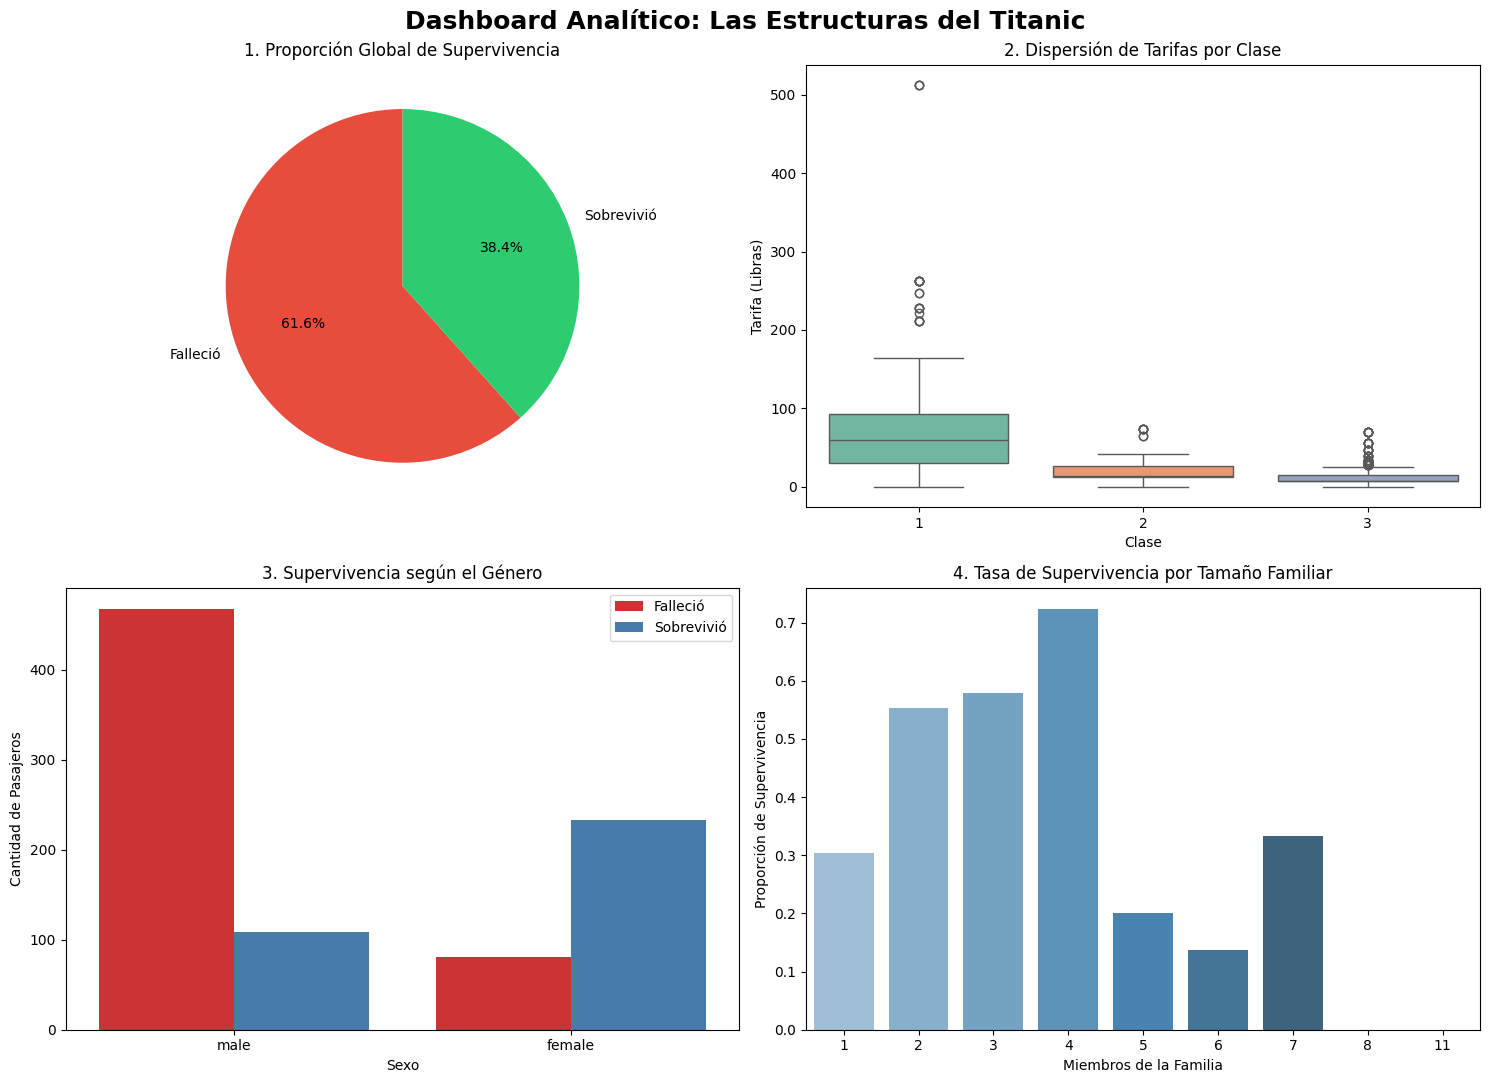

In [24]:
# Configurar el lienzo de 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Dashboard Analítico: Las Estructuras del Titanic', fontsize=18, fontweight='bold')

# 1. Gráfico Circular: Supervivencia Global
survived_data = df['Survived'].value_counts()
axes[0, 0].pie(survived_data, labels=['Falleció', 'Sobrevivió'], autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[0, 0].set_title('1. Proporción Global de Supervivencia')

# 2. Gráfico de Caja: Tarifas por Clase
sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('2. Dispersión de Tarifas por Clase')
axes[0, 1].set_xlabel('Clase')
axes[0, 1].set_ylabel('Tarifa (Libras)')

# 3. Gráfico de Barras: Género y Supervivencia (Simplificado para el subplot)
sns.countplot(data=df, x='Sex', hue='Survived', palette='Set1', ax=axes[1, 0])
axes[1, 0].set_title('3. Supervivencia según el Género')
axes[1, 0].set_xlabel('Sexo')
axes[1, 0].set_ylabel('Cantidad de Pasajeros')
axes[1, 0].legend(['Falleció', 'Sobrevivió'])

# 4. Gráfico de Barras: Tamaño de la Familia
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
sns.barplot(data=df, x='FamilySize', y='Survived', palette='Blues_d', errorbar=None, ax=axes[1, 1])
axes[1, 1].set_title('4. Tasa de Supervivencia por Tamaño Familiar')
axes[1, 1].set_xlabel('Miembros de la Familia')
axes[1, 1].set_ylabel('Proporción de Supervivencia')

plt.tight_layout()
plt.show()

### ⚓ Reflexión Final
Más allá del código y los gráficos, este dataset representa personas reales. Responde brevemente a estas preguntas de reflexión:  

*   ¿Qué gráfico te resultó más difícil de elegir? ¿Por qué?

*   ¿Hubo alguna pregunta donde varios tipos de gráfico eran igualmente
válidos? ¿Cuál elegiste al final y por qué?

*   ¿Qué hallazgo de los datos te sorprendió más?

---

*   ¿Qué gráfico resultó más difícil de elegir? ¿Por qué?
    El de la Pregunta 10 (Edad vs. Supervivencia). Al ser la edad una variable con mucha dispersión, un gráfico de barras se saturaba. Fue un reto elegir el histograma con curvas de densidad (KDE) porque requería un balance preciso para que las curvas de "Sobrevivió" y "Falleció" no se solaparan de forma caótica, permitiendo ver con claridad los picos de edad exacta.


*   ¿Hubo alguna pregunta donde varios tipos de gráfico eran igualmente válidos? ¿Cuál elegiste al final y por qué?

    Sí, la Pregunta 9 (Género y Clase frente a Supervivencia). El gráfico de barras apiladas o un gráfico de barras agrupadas ambos mostrarían la información necesario; al final elegí un gráfico por paneles (Facet Grid) porque, al meter una tercera variable categórica (la clase), meter todo en un solo plano saturaba los ejes. Dividirlo en tres subgráficos limpios facilitó una lectura inmediata

*   ¿Qué hallazgo de los datos te sorprendió más?

    El impacto del tamaño familiar (Pregunta 13). Es impactante ver cómo los datos respaldan la trágica hipótesis: Tener de 1 a 3 familiares a bordo aumentaba las posibilidades de salir vivo gracias al apoyo mutuo, pero superar ese límite (familias de 5 o más personas) reducía la supervivencia casi a cero, mostrando el coste letal de negarse a separar a los seres queridos en el caos.